In [35]:
from pathlib import Path
import sys
import time
import json
import joblib

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [36]:
DATA = PROJECT_ROOT / "data" / "processed"

X_train = pd.read_csv(DATA / "X_train_scaled.csv")

X_test = pd.read_csv(DATA / "X_test_scaled.csv")

y_train = pd.read_csv(DATA / "y_train.csv")["Label"]

y_test = pd.read_csv(DATA / "y_test.csv")["Label"]

label_encoder = joblib.load(DATA / "label_encoder.pkl")

print(X_train.shape)

print(X_test.shape)

(72000, 20)
(18000, 20)


In [61]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1
)

start = time.time()

rf.fit(
    X_train,
    y_train
)

training_time = time.time() - start

print()

print("Training Time :", training_time)


Training Time : 84.99372386932373


In [62]:
start = time.time()

y_pred = rf.predict(X_test)

prediction_time = time.time() - start

print()

print("Prediction Time :", prediction_time)


Prediction Time : 0.8207108974456787


In [63]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*60)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("="*60)

Accuracy : 0.9601666666666666
Precision : 0.9602540517817445
Recall : 0.9601666666666666
F1 : 0.9601381058220961


In [64]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

        8PSK       0.88      0.88      0.88      2000
      AM-DSB       1.00      1.00      1.00      2000
      AM-SSB       0.96      1.00      0.98      2000
        BPSK       0.98      0.98      0.98      2000
       CPFSK       0.96      0.95      0.96      2000
        GFSK       0.98      0.98      0.98      2000
        PAM4       0.99      0.98      0.98      2000
       QAM64       0.98      0.96      0.97      2000
        QPSK       0.91      0.90      0.91      2000

    accuracy                           0.96     18000
   macro avg       0.96      0.96      0.96     18000
weighted avg       0.96      0.96      0.96     18000



In [65]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_df

,8PSK,AM-DSB,AM-SSB,BPSK,CPFSK,GFSK,PAM4,QAM64,QPSK
8PSK,1765,0,18,1,42,11,1,22,140
AM-DSB,0,1999,0,1,0,0,0,0,0
AM-SSB,0,0,2000,0,0,0,0,0,0
BPSK,0,0,18,1966,0,0,14,1,1
CPFSK,51,0,0,0,1907,17,0,0,25
GFSK,9,1,0,0,21,1965,0,0,4
PAM4,1,0,16,29,0,0,1951,3,0
QAM64,42,0,19,2,0,0,1,1928,8
QPSK,141,0,19,0,10,12,3,13,1802


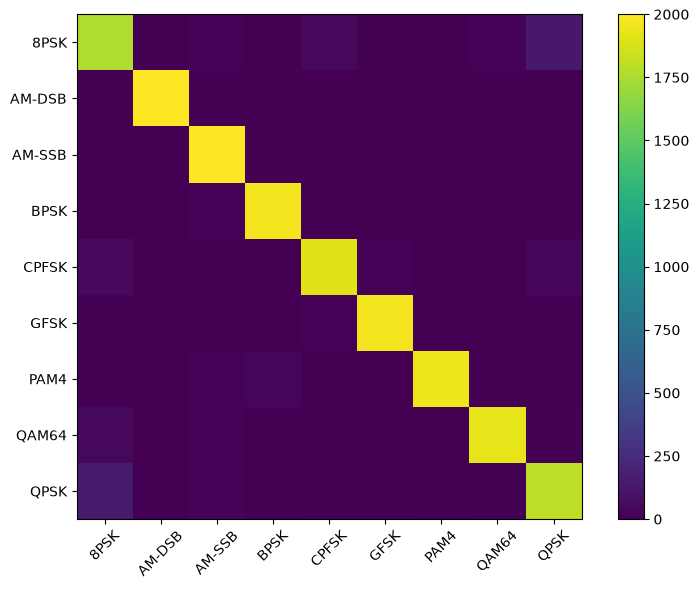

In [66]:
plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.colorbar()

plt.tight_layout()

plt.show()

In [67]:
per_class = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({

    "Modulation":label_encoder.classes_,

    "Accuracy":per_class

})

per_class_df

,Modulation,Accuracy
0,8PSK,0.8825
1,AM-DSB,0.9995
2,AM-SSB,1.0000
3,BPSK,0.9830
4,CPFSK,0.9535
5,GFSK,0.9825
6,PAM4,0.9755
7,QAM64,0.9640
8,QPSK,0.9010


In [68]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
13,M20,0.106188
1,AmplitudeStd,0.088279
4,FrequencyStd,0.084285
7,SigmaZ2,0.080459
3,PhaseStd,0.068639
15,R1,0.062281
6,SigmaDP,0.060756
8,BlindSNR,0.050119
18,R4,0.047946
10,SpectralEntropy,0.045435


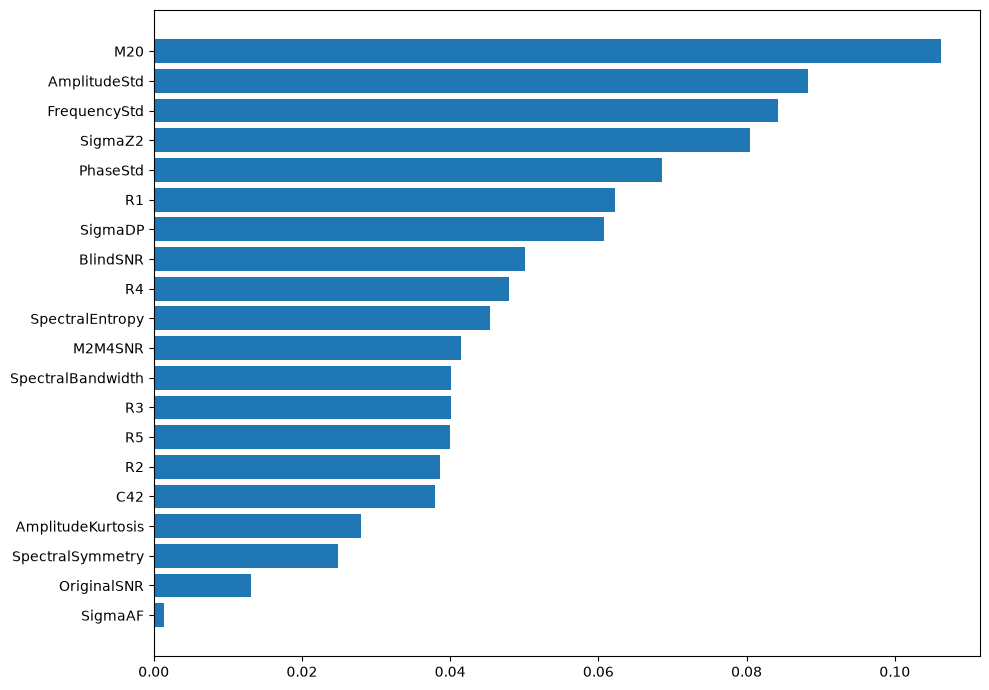

In [69]:
plt.figure(figsize=(10,7))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [70]:
original = pd.read_csv(DATA / "feature_dataset_clean.csv")

test_index = y_test.index

snr = original.loc[test_index, "OriginalSNR"]

results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred,

    "SNR":snr

})

snr_accuracy = results.groupby("SNR").apply(

    lambda x:(x.Actual==x.Predicted).mean()

)

snr_accuracy

SNR
0     0.966000
2     0.959000
4     0.961000
6     0.958667
8     0.960000
10    0.966000
12    0.957667
14    0.961000
16    0.962000
dtype: float64

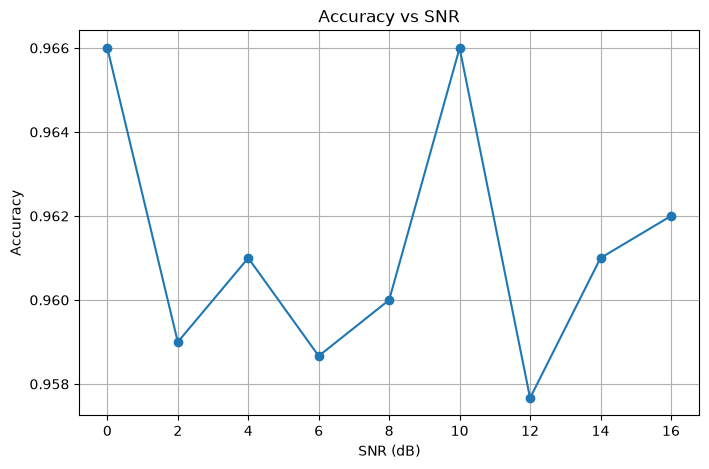

In [71]:
plt.figure(figsize=(8,5))

plt.plot(

    snr_accuracy.index,

    snr_accuracy.values,

    marker="o"

)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Accuracy")

plt.title("Accuracy vs SNR")

plt.show()

In [72]:
UNKNOWN_THRESHOLD = 0.75

def predict_signal(sample):

    prob = rf.predict_proba(sample)

    confidence = np.max(prob)

    prediction = np.argmax(prob)

    if confidence < UNKNOWN_THRESHOLD:

        return "Unknown", confidence

    return label_encoder.inverse_transform([prediction])[0], confidence

In [73]:
prediction, confidence = predict_signal(

    X_test.iloc[[0]]

)

print(prediction)

print(confidence)

PAM4
1.0


In [74]:
MODEL = PROJECT_ROOT / "models"

MODEL.mkdir(

    parents=True,

    exist_ok=True

)

joblib.dump(

    rf,

    MODEL / "random_forest.pkl"

)

metadata = {

    "accuracy":float(accuracy),

    "precision":float(precision),

    "recall":float(recall),

    "f1":float(f1),

    "training_time":training_time,

    "prediction_time":prediction_time,

    "threshold":UNKNOWN_THRESHOLD

}

with open(

    MODEL / "random_forest_metadata.json",

    "w"

) as f:

    json.dump(

        metadata,

        f,

        indent=4

    )

print("Model Saved Successfully")

Model Saved Successfully


In [75]:
REPORT = PROJECT_ROOT / "results" / "reports"

REPORT.mkdir(

    parents=True,

    exist_ok=True

)

importance.to_csv(

    REPORT / "feature_importance.csv",

    index=False

)

per_class_df.to_csv(

    REPORT / "per_class_accuracy.csv",

    index=False

)

cm_df.to_csv(

    REPORT / "confusion_matrix.csv"

)

print("Reports Saved")

Reports Saved
